<a href="https://colab.research.google.com/github/NeoByteVoyager/DeepLearning/blob/main/DeepLearning/Notes%20/NeuralNetworkTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What to do if Neural Network Training fails?

## 一.Local minima and saddle point

### 1.Definition

**Optimzation fails（loss can not be lower）is because:**
  - critical point(gradient is close to zero):
    - local minima
    - saddle point

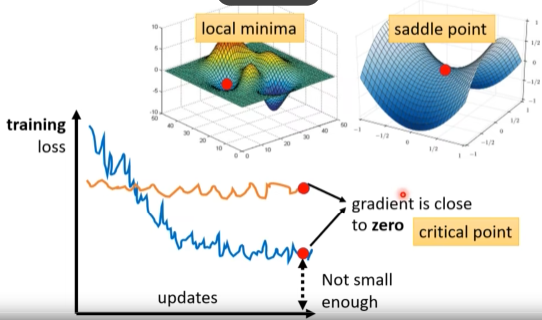

### 2.Local minima vs Saddle point

When $\nabla L(\theta) \approx 0$ (gradients equals to zero),we do not know how to update parameters to make the loss lower.   
We have to use **Hessian matrix**:
$$H = \begin{bmatrix}
\frac{\partial^2 L}{\partial \theta_1^2} & \frac{\partial^2 L}{\partial \theta_1 \partial \theta_2} \\
\frac{\partial^2 L}{\partial \theta_2 \partial \theta_1} & \frac{\partial^2 L}{\partial \theta_2^2}
\end{bmatrix}$$
The loss function near $\theta_0$ can write by **Taylor Series**:
$$L(\theta) \approx L(\theta_0) + (\theta - \theta_0)^T g + \frac{1}{2}(\theta - \theta_0)^T H (\theta - \theta_0)$$
(This is similar to:$f(x) \approx f(x_0) + f'(x_0)(x - x_0) + \frac{1}{2}f''(x_0)(x - x_0)^2$)


When gradient is 0(g=0), The value of $L$ is all relative to $H$   
If $v=\theta - \theta_0$ ,the symbol of $v^T H v$ is equal to the **eigenvalues** of $H$
 -  **Local min:** The eigenvalues of $H$ is all **positive**(positive definite)
 -  **Local max:** The eigenvalues of $H$ is all **negative**(negative definite)
 -  **Saddle point:** The eigenvalues of $H$ has **positive ones** and **negative ones**

### 3.Saddle point in high dimension is more typical

If **the possibility of** loss on some dimension is local minima is 0.5,the model has 100,000 parameters (100,000 dimension)   
The possibility of all the dimension is on local minima is $0.5^{100,000}$,which is so low   
So all the critical points are almost **saddle points**


### 4.What to do when on the saddle point

1. Find the **negative eigenvalue$ (\lambda < 0)$** of $H$
2. Find the **eigenvector** $u$
3. According to:$$\frac{1}{2} u^T H u = \frac{1}{2} u^T (\lambda u) = \frac{1}{2} \lambda \|u\|^2 < 0$$
we can update parameters towards $u$ :$\theta = \theta_0 + u$
4. The loss will be smaller